In [2]:
%load_ext autoreload
%autoreload 2
from ultralytics import YOLO
from pathlib import Path

In [ ]:
TRAIN = False
if TRAIN:
    model = YOLO("yolo11m-seg.pt")
    results = model.train(
        data="/home/dherrera/data/elephants/segmentation/yolo/dataset.yml",
        epochs=100,
        imgsz=640,
    )
    print(results)
else:
    model = YOLO(
        Path(
            "/home/dherrera/git/zoo_vision/models/segmentation/yolo/all_v3/weights/best.pt"
        ),
        task="segment",
    )

In [23]:
import torch

model.export(format="onnx", device=torch.device("cuda"))
model.export(format="torchscript", device=torch.device("cuda"))
model_ts = torch.jit.load(
    "/home/dherrera/git/zoo_vision/runs/segment/train/weights/best.torchscript"
)

YOLO11m-seg summary (fused): 138 layers, 22,336,083 parameters, 0 gradients, 123.0 GFLOPs

PyTorch: starting from '/home/dherrera/git/zoo_vision/models/segmentation/yolo/all_v3/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) ((1, 37, 8400), (1, 32, 160, 160)) (43.1 MB)

ONNX: starting export with onnx 1.17.0 opset 19...
ONNX: slimming with onnxslim 0.1.50...
ONNX: export success ✅ 1.6s, saved as '/home/dherrera/git/zoo_vision/models/segmentation/yolo/all_v3/weights/best.onnx' (85.5 MB)

Export complete (1.9s)
Results saved to /home/dherrera/git/zoo_vision/models/segmentation/yolo/all_v3/weights
Predict:         yolo predict task=segment model=/home/dherrera/git/zoo_vision/models/segmentation/yolo/all_v3/weights/best.onnx imgsz=640  
Validate:        yolo val task=segment model=/home/dherrera/git/zoo_vision/models/segmentation/yolo/all_v3/weights/best.onnx imgsz=640 data=/home/dherrera/data/elephants/segmentation/yolo/dataset.yml  
Visualize:       https://ne

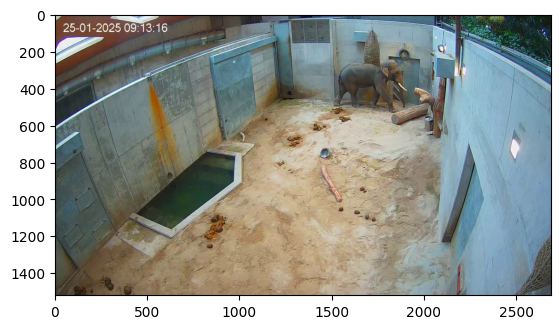

In [ ]:
import matplotlib.pylab as plt
from PIL import Image
import numpy as np

img = Image.open(
    "/home/dherrera/data/elephants/segmentation/v1/good/zag_elp_cam_018/ZAG-ELP-CAM-018-25.01.2025-060848-100848_00276799_img.jpg"
)
img = np.asarray(img)
plt.imshow(img)

In [ ]:
from ultralytics.models.yolo.segment import SegmentationPredictor
from tqdm.auto import tqdm

predictor = SegmentationPredictor()
predictor.setup_model(
    Path(
        "/home/dherrera/git/zoo_vision/models/segmentation/yolo/all_v3/weights/best.pt"
    )
)
predictor.setup_source([img])

imt = predictor.preprocess([img])
predictor.batch = imt
for i in tqdm(range(1000)):
    preds = predictor.model(imt)

results = predictor.postprocess(preds, imt, [img])
results

Ultralytics 8.3.114 🚀 Python-3.11.12 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 4080 SUPER, 15921MiB)


  0%|          | 0/1000 [00:00<?, ?it/s]

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: ultralytics.engine.results.Masks object
 names: {0: 'elephant'}
 obb: None
 orig_img: array([[[210, 210, 210],
         [211, 211, 211],
         [215, 213, 214],
         ...,
         [ 32,  40,  29],
         [ 23,  31,  20],
         [ 18,  26,  15]],
 
        [[211, 211, 211],
         [213, 213, 213],
         [217, 215, 216],
         ...,
         [ 27,  35,  24],
         [ 22,  30,  19],
         [ 20,  28,  17]],
 
        [[214, 214, 214],
         [216, 216, 216],
         [221, 219, 220],
         ...,
         [ 25,  33,  22],
         [ 26,  34,  23],
         [ 27,  35,  24]],
 
        ...,
 
        [[ 76,  71,  68],
         [ 61,  56,  53],
         [ 60,  54,  54],
         ...,
         [ 64,  74,  84],
         [ 63,  73,  83],
         [ 62,  72,  82]],
 
        [[ 69,  64,  61],
         [ 63,  58,  55],
         [ 63,  58,  

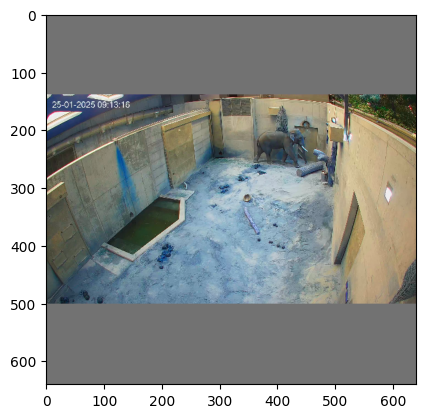

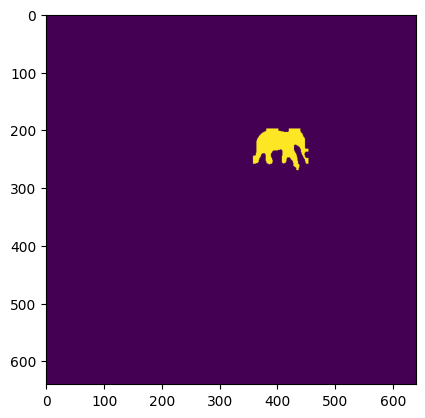

In [ ]:
plt.imshow(imt[0].permute([1, 2, 0]).cpu().numpy())
plt.show()
plt.imshow(results[0].masks.data.cpu().squeeze())
plt.show()